In [1]:
import os
import sys
import tensorflow as tf
import pandas as pd
import numpy as np

# Import from your library
from utils.tf_global_search import GlobalSearchTF, run_mlp_search, run_deepsets_search
from utils.tf_visualization import plot_pareto_fronts, plot_3d_pareto_front_heatmap

%matplotlib inline

2025-08-18 07:34:31.248731: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-18 07:34:31.252171: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-18 07:34:31.263189: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755527671.281164  471714 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755527671.286627  471714 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755527671.299871  471714 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [ ]:

# --- Experiment Configuration ---
MODEL_TYPE = "mlp"              # "mlp" or "deepsets"
N_TRIALS = 30                   # Number of optimization trials
EPOCHS = 20                     # Training epochs for each trial
SUBSET_SIZE = 5000              # Use a smaller subset for faster runs
RESIZE_VAL = 8                  # Resize images to 8x8
RESULTS_DIR = "./results/results_tf_clean"
USE_HARDWARE_METRICS = True    # Set to True if you have rule4ml installed

# --- Objectives Configuration ---
OBJECTIVE_NAMES = ['accuracy', 'bops', 'avg_resource', 'clock_cycles']
MAXIMIZE_FLAGS = [True, False, False, False]  # True = maximize, False = minimize
OBJECTIVE_INFO = list(zip(OBJECTIVE_NAMES, MAXIMIZE_FLAGS))

# --- Search Space Configuration ---
SEARCH_SPACE_PATH = 'examples/mnist_search_spaces.yaml'  # Optional: use custom search space



## Method 1 using convenience function

In [3]:
print("Method 1: Using convenience function")
print("\n" + "="*50)


# Run MLP search with convenience function
study, searcher = run_mlp_search(
    search_space_path=SEARCH_SPACE_PATH,
    results_dir=RESULTS_DIR,
    n_trials=N_TRIALS,
    epochs=EPOCHS,
    subset_size=SUBSET_SIZE,
    resize_val=RESIZE_VAL,
    use_hardware_metrics=USE_HARDWARE_METRICS
)


Method 1: Using convenience function


Starting MLP Global Search on MNIST



2025-08-18 07:34:35.212001: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
[I 2025-08-18 07:34:35,284] A new study created in memory with name: no-name-1d2e8c54-4521-49ea-8c53-0fc925b5292c


Data loaded and preprocessed:
  Resize: 8x8
  x_train shape: (5000, 64), x_val shape: (5000, 64)
  y_train shape: (5000, 10), y_val shape: (5000, 10)


[I 2025-08-18 07:34:40,899] Trial 0 finished with values: [0.7662000060081482, 5171072.0, 13.427500000000002, 117.48] and parameters: {'num_layers': 3, 'hidden_units1': 32, 'activation1': 'sigmoid', 'batchnorm1': False, 'hidden_units2': 64, 'activation2': 'sigmoid', 'batchnorm2': True}.


Trial 0: Accuracy=0.7662, BOPs=5171072.0, Avg Resource=13.43, Clock Cycles=117.48


...

Trial 27: Accuracy=0.7980, BOPs=5761280.0, Avg Resource=12.64, Clock Cycles=89.48


[I 2025-08-18 07:37:03,599] Trial 28 finished with values: [0.699400007724762, 1573120.0, 5.717499999999999, 106.43] and parameters: {'num_layers': 3, 'hidden_units1': 16, 'activation1': 'sigmoid', 'batchnorm1': False, 'hidden_units2': 16, 'activation2': 'tanh', 'batchnorm2': False}.


Trial 28: Accuracy=0.6994, BOPs=1573120.0, Avg Resource=5.72, Clock Cycles=106.43


[I 2025-08-18 07:37:09,703] Trial 29 finished with values: [0.7789999842643738, 2937728.0, 5.35, 86.36] and parameters: {'num_layers': 3, 'hidden_units1': 16, 'activation1': 'sigmoid', 'batchnorm1': True, 'hidden_units2': 64, 'activation2': 'sigmoid', 'batchnorm2': True}.


Trial 29: Accuracy=0.7790, BOPs=2937728.0, Avg Resource=5.35, Clock Cycles=86.36

CSV results saved to ./results/results_tf_clean/mlp_search_results.csv

BEST TRIALS FOUND BY OPTUNA

Rank 1 (Trial 1):
  Values: {'accuracy': 0.8443999886512756, 'bops': 10332352.0, 'avg_resource': 72.0525, 'clock_cycles': 294.53}
  Params: {'num_layers': 2, 'hidden_units1': 128, 'activation1': 'relu', 'batchnorm1': True}

Rank 2 (Trial 2):
  Values: {'accuracy': 0.770799994468689, 'bops': 2584128.0, 'avg_resource': 7.695, 'clock_cycles': 60.91}
  Params: {'num_layers': 2, 'hidden_units1': 32, 'activation1': 'tanh', 'batchnorm1': False}

Rank 3 (Trial 11):
  Values: {'accuracy': 0.7802000045776367, 'bops': 1292544.0, 'avg_resource': 3.5275, 'clock_cycles': 74.61}
  Params: {'num_layers': 2, 'hidden_units1': 16, 'activation1': 'tanh', 'batchnorm1': True}

Rank 4 (Trial 13):
  Values: {'accuracy': 0.7716000080108643, 'bops': 1573120.0, 'avg_resource': 3.505, 'clock_cycles': 76.74}
  Params: {'num_layers': 3

## Method 2: Using the GlobalSearchTF class directly (More control)


In [4]:
print("\n" + "="*50)
print("Method 2: Using GlobalSearchTF class directly")
print("="*50)

# Initialize the searcher
searcher_manual = GlobalSearchTF(
    search_space_path=SEARCH_SPACE_PATH,
    results_dir=RESULTS_DIR + "_manual"
)

# Run the search with custom parameters
study_manual = searcher_manual.run_search(
    model_type=MODEL_TYPE,
    n_trials=N_TRIALS,
    epochs=EPOCHS,
    dataset='mnist',
    subset_size=SUBSET_SIZE,
    resize_val=RESIZE_VAL,
    objectives=OBJECTIVE_NAMES,
    maximize_flags=MAXIMIZE_FLAGS,
    use_hardware_metrics=USE_HARDWARE_METRICS,
    verbose=True
)




Method 2: Using GlobalSearchTF class directly

Starting MLP Global Search on MNIST



[I 2025-08-18 07:37:09,958] A new study created in memory with name: no-name-b972cc4a-de59-40c2-baac-f00a91a06e23


Data loaded and preprocessed:
  Resize: 8x8
  x_train shape: (5000, 64), x_val shape: (5000, 64)
  y_train shape: (5000, 10), y_val shape: (5000, 10)


[I 2025-08-18 07:37:15,382] Trial 0 finished with values: [0.7911999821662903, 5171072.0, 13.7975, 117.96] and parameters: {'num_layers': 3, 'hidden_units1': 32, 'activation1': 'tanh', 'batchnorm1': False, 'hidden_units2': 64, 'activation2': 'sigmoid', 'batchnorm2': True}.


Trial 0: Accuracy=0.7912, BOPs=5171072.0, Avg Resource=13.80, Clock Cycles=117.96


...

Trial 27: Accuracy=0.7344, BOPs=5166976.0, Avg Resource=11.51, Clock Cycles=88.45


[I 2025-08-18 07:39:45,143] Trial 28 finished with values: [0.8226000070571899, 5171072.0, 6.9325, 97.3] and parameters: {'num_layers': 3, 'hidden_units1': 32, 'activation1': 'relu', 'batchnorm1': True, 'hidden_units2': 64, 'activation2': 'sigmoid', 'batchnorm2': True}.


Trial 28: Accuracy=0.8226, BOPs=5171072.0, Avg Resource=6.93, Clock Cycles=97.3


[I 2025-08-18 07:39:50,016] Trial 29 finished with values: [0.7766000032424927, 2584128.0, 7.695, 60.91] and parameters: {'num_layers': 2, 'hidden_units1': 32, 'activation1': 'tanh', 'batchnorm1': False}.


Trial 29: Accuracy=0.7766, BOPs=2584128.0, Avg Resource=7.70, Clock Cycles=60.91

CSV results saved to ./results/results_tf_clean_manual/mlp_search_results.csv

BEST TRIALS FOUND BY OPTUNA

Rank 1 (Trial 5):
  Values: {'accuracy': 0.6607999801635742, 'bops': 716992.0, 'avg_resource': 2.935, 'clock_cycles': 94.77}
  Params: {'num_layers': 3, 'hidden_units1': 8, 'activation1': 'relu', 'batchnorm1': True, 'hidden_units2': 8, 'activation2': 'tanh', 'batchnorm2': False}

Rank 2 (Trial 6):
  Values: {'accuracy': 0.7111999988555908, 'bops': 646592.0, 'avg_resource': 3.4050000000000002, 'clock_cycles': 105.3}
  Params: {'num_layers': 2, 'hidden_units1': 8, 'activation1': 'relu', 'batchnorm1': False}

Rank 3 (Trial 7):
  Values: {'accuracy': 0.7764000296592712, 'bops': 2028096.0, 'avg_resource': 3.7125, 'clock_cycles': 90.03}
  Params: {'num_layers': 3, 'hidden_units1': 16, 'activation1': 'tanh', 'batchnorm1': False, 'hidden_units2': 32, 'activation2': 'sigmoid', 'batchnorm2': True}

Rank 4 (Tr

## Analyze the results


ANALYZING RESULTS

Results Summary:
Total trials completed: 30
Best accuracy achieved: 0.8560
Lowest BOPs: 646592.0

Results DataFrame:
   trial  accuracy        bops  avg_resource  clock_cycles  \
0      0    0.7662   5171072.0       13.4275        117.48   
1      1    0.8444  10332352.0       72.0525        294.53   
2      2    0.7708   2584128.0        7.6950         60.91   
3      3    0.7932   5166976.0       11.0325         89.21   
4      4    0.7820   5166976.0       11.6675         88.90   

                                              params  
0  {'num_layers': 3, 'hidden_units1': 32, 'activa...  
1  {'num_layers': 2, 'hidden_units1': 128, 'activ...  
2  {'num_layers': 2, 'hidden_units1': 32, 'activa...  
3  {'num_layers': 2, 'hidden_units1': 64, 'activa...  
4  {'num_layers': 2, 'hidden_units1': 64, 'activa...  

VISUALIZING RESULTS

--- Generating 2D Pareto Fronts ---
2D Pareto fronts plot saved to ./results/results_tf_clean/pareto_fronts_2d.png


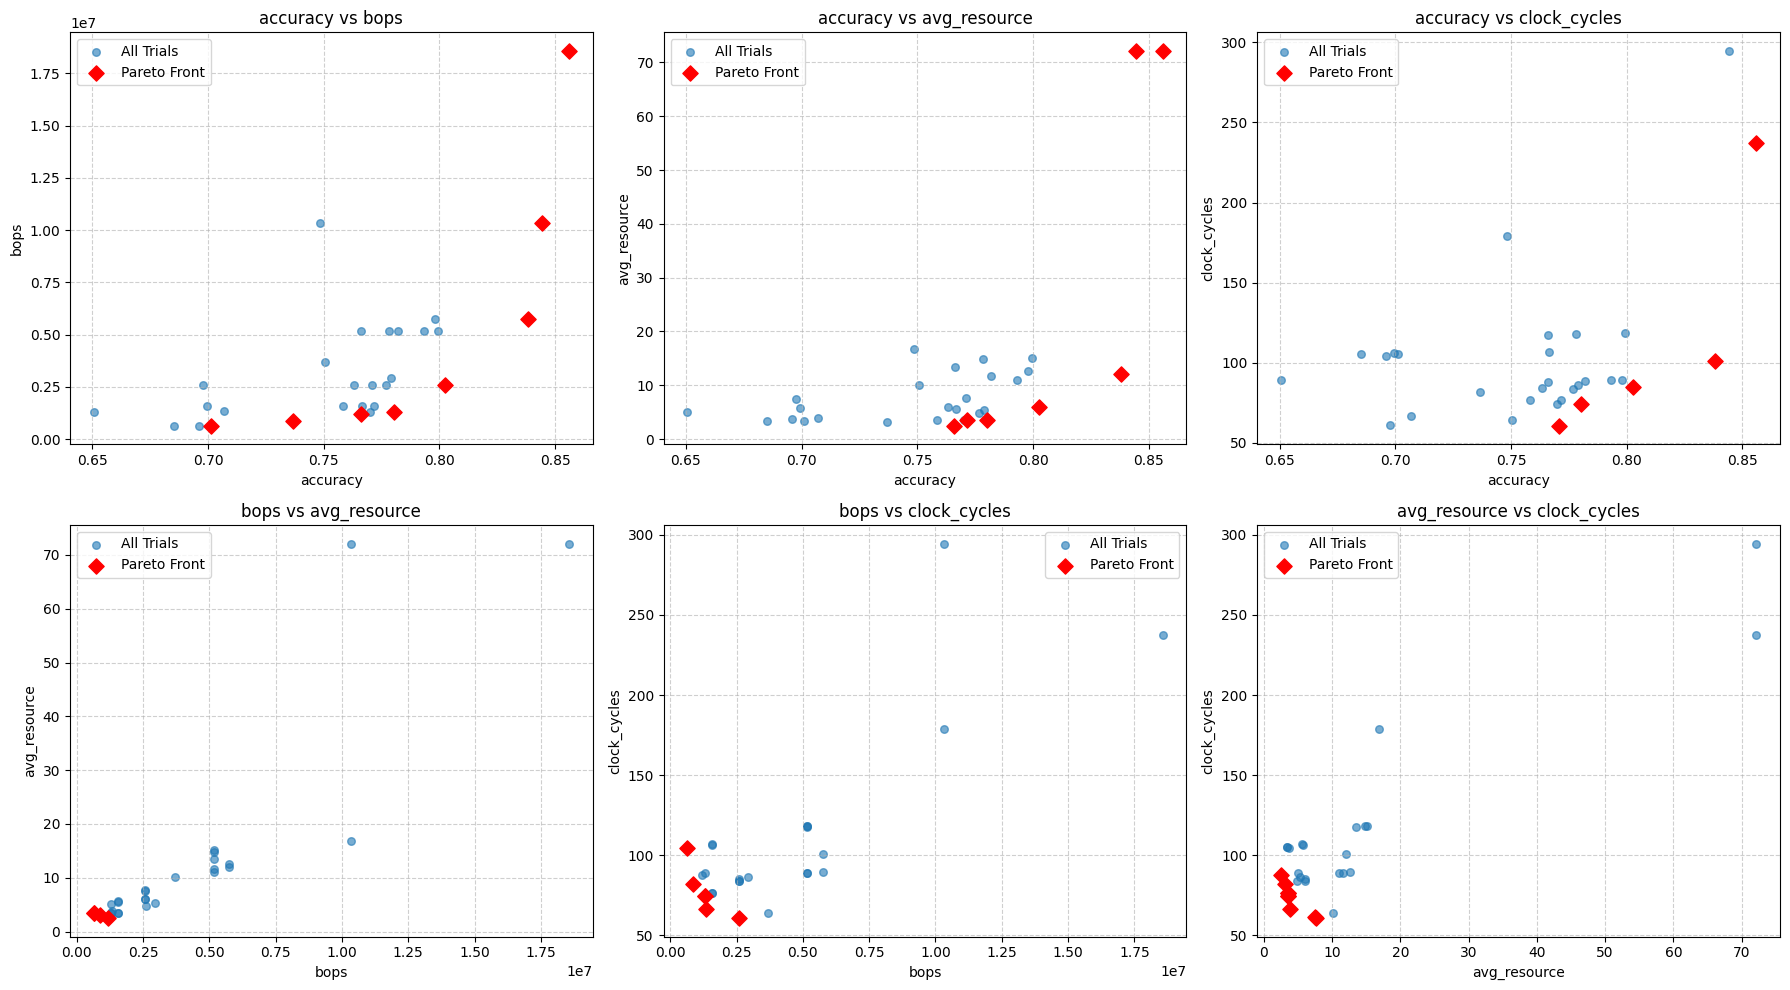


--- Generating 3D Pareto Front Heatmap ---
3D Pareto front plot saved to ./results/results_tf_clean/pareto_front_3d.html



All plots saved to: ./results/results_tf_clean


In [5]:
print("\n" + "="*50)
print("ANALYZING RESULTS")
print("="*50)

# Get results as DataFrame
results_df = searcher.get_results_dataframe()

# Display basic statistics
print("\nResults Summary:")
print(f"Total trials completed: {len(results_df)}")
print(f"Best accuracy achieved: {results_df['accuracy'].max():.4f}")
print(f"Lowest BOPs: {results_df['bops'].min()}")

print("\nResults DataFrame:")
print(results_df.head())


print("\n" + "="*50)
print("VISUALIZING RESULTS")
print("="*50)

if not results_df.empty:
    # Generate and display the 2D Pareto front plots
    print("\n--- Generating 2D Pareto Fronts ---")
    plot_pareto_fronts(results_df, OBJECTIVE_INFO, save_dir=searcher.results_dir)

    # Generate and display the 3D Pareto front plot if enough objectives exist
    if len(OBJECTIVE_NAMES) >= 4:
        print("\n--- Generating 3D Pareto Front Heatmap ---")
        plot_3d_pareto_front_heatmap(results_df, OBJECTIVE_INFO[:4], save_dir=searcher.results_dir)
    else:
        print("\nSkipping 3D plot: At least 4 objectives are required.")
        
    print(f"\nAll plots saved to: {searcher.results_dir}")
else:
    print("No results to plot.")



## Advanced Usage: Custom Objective Function

In [6]:
def create_custom_objective_example():
    """
    Example of how to create a custom objective function for specific needs.
    This is useful when you need more control over the optimization process.
    """
    # Load data manually
    from utils.tf_data_preprocessing import load_and_preprocess_mnist
    x_train, y_train, x_val, y_val = load_and_preprocess_mnist(
        resize_val=RESIZE_VAL, subset_size=SUBSET_SIZE, flatten=True, one_hot=True
    )
    
    # Initialize searcher
    custom_searcher = GlobalSearchTF(results_dir=RESULTS_DIR + "_custom")
    
    # Create custom objective with specific parameters
    objective = custom_searcher.create_mlp_objective(
        x_train, y_train, x_val, y_val,
        epochs=EPOCHS,
        use_hardware_metrics=USE_HARDWARE_METRICS,
        verbose=True
    )
    
    # You can now use this objective with Optuna directly for maximum control
    import optuna
    directions = ["maximize" if flag else "minimize" for flag in MAXIMIZE_FLAGS]
    study = optuna.create_study(directions=directions, sampler=optuna.samplers.NSGAIISampler())
    
    # Run a few trials as example
    study.optimize(objective, n_trials=5)
    
    print("Custom objective function example completed!")
    return study, custom_searcher

# Run the custom example
# custom_study, custom_searcher = create_custom_objective_example()



## DeepSets Example (if you want to try a different architecture)


In [7]:
print("\n" + "="*50)
print("BONUS: DeepSets Architecture Example")
print("="*50)

def run_deepsets_example():
    """
    Example of running DeepSets architecture search.
    Note: This requires different data preprocessing (no flattening).
    """
    print("Running DeepSets search example...")
    
    # For DeepSets, we need 3D input data (batch, particles, features)
    # This is a simplified example - you'd normally load proper set data
    deepsets_study, deepsets_searcher = run_deepsets_search(
        results_dir=RESULTS_DIR + "_deepsets",
        n_trials=5,  # Fewer trials for demo
        epochs=3,
        subset_size=1000,
        use_hardware_metrics=USE_HARDWARE_METRICS
    )
    
    print("DeepSets example completed!")
    return deepsets_study, deepsets_searcher

# Uncomment to run DeepSets example
deepsets_study, deepsets_searcher = run_deepsets_example()


# %%






BONUS: DeepSets Architecture Example
Running DeepSets search example...

Starting DEEPSETS Global Search on MNIST



[I 2025-08-18 07:39:54,407] A new study created in memory with name: no-name-11ce77c8-c7a9-49bf-ac24-aa610b1b39e1


Data loaded and preprocessed:
  Resize: 8x8
  x_train shape: (1000, 8, 8, 1), x_val shape: (1000, 8, 8, 1)
  y_train shape: (1000,), y_val shape: (1000,)


/home/users/ddemler/miniconda3/envs/FastMLTutorial/lib/python3.11/site-packages/keras/src/layers/layer.py:421: UserWarning:

`build()` was called on layer 'deep_sets_architecture_tf', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.

[W 2025-08-18 07:39:56,429] Trial 0 failed with parameters: {'phi_num_layers': 2, 'phi_units': 16, 'phi_activation': 'relu', 'phi_batchnorm': False, 'bottleneck_dim': 5, 'rho_num_layers': 3, 'rho_units': 32, 'rho_activation': 'relu', 'rho_batchnorm': False, 'aggregator_type': 'max'} because of the following error: TypeError("GlobalSearchTF.calculate_hardware_metrics() missing 1 required positional argument: 'input_size'").
Traceback (most recent call last):
  File "/home/users/ddemler/miniconda3/envs/FastMLTutorial/lib/python3.11/sit

TypeError: GlobalSearchTF.calculate_hardware_metrics() missing 1 required positional argument: 'input_size'